<a href="https://colab.research.google.com/github/nguyenhoangan7941/Homework/blob/main/GPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-fuzzy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
import seaborn as sns
data=pd.read_csv('/content/KHẢO SÁT THÓI QUEN HỌC TẬP VÀ GPA (Câu trả lời).csv')
data.head()


,student_year,study_hours\n,subjects_count,attendance,study_method,sleep_hours,social_media_hours,part_time_job,club_activity,gpa
0,Năm 1,36.0,8,100,Kết hợp cả hai,6.0,4.0,Không,Không,3.80
1,Năm 4,9.0,7,100,Kết hợp cả hai,7.0,3.0,Không,Có,3.20
2,Năm 1,20.0,9,100,Kết hợp cả hai,6.0,5.0,Không,Không,3.78
3,Năm 1,80.0,8,100,Kết hợp cả hai,6.0,8.0,Không,Không,3.76
4,Năm 2,18.0,6,100,Học nhóm,6.0,3.0,Có,Không,3.10


In [ ]:
# CHECK DATA

# thông tin dataset
data.info()

# thống kê cơ bản
data.describe()

# kiểm tra missing values
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_year        297 non-null    object 
 1   study_hours
        297 non-null    float64
 2   subjects_count      297 non-null    int64  
 3   attendance          297 non-null    int64  
 4   study_method        297 non-null    object 
 5   sleep_hours         297 non-null    float64
 6   social_media_hours  297 non-null    float64
 7   part_time_job       297 non-null    object 
 8   club_activity       297 non-null    object 
 9   gpa                 297 non-null    float64
dtypes: float64(4), int64(2), object(4)
memory usage: 23.3+ KB


,0
student_year,0
study_hours\n,0
subjects_count,0
attendance,0
study_method,0
sleep_hours,0
social_media_hours,0
part_time_job,0
club_activity,0
gpa,0


In [ ]:
data.columns

Index(['student_year', 'study_hours\n', 'subjects_count', 'attendance',
       'study_method', 'sleep_hours', 'social_media_hours', 'part_time_job',
       'club_activity', 'gpa'],
      dtype='object')

In [ ]:
data = data.rename(columns={
    "study_hours\n": "study_hours"
})

In [ ]:
# 6. REMOVE OUTLIERS

data = data[data["study_hours"] <= 70]

data = data[data["subjects_count"] <= 12]

data = data[data["attendance"] <= 100]

data = data[data["sleep_hours"] <= 12]

data = data[data["social_media_hours"] <= 15]

data = data[data["gpa"] <= 4]
data = data[data["gpa"] >= 1.0]

# check remaining rows
data.shape

(276, 10)

In [ ]:
data["part_time_job"] = data["part_time_job"].replace({
    "Có": 1,
    "Không": 0
})

data["club_activity"] = data["club_activity"].replace({
    "Có": 1,
    "Không": 0
})

data["study_method"] = data["study_method"].replace({
    "Tự học": 0,
    "Học nhóm": 1,
    "Kết hợp cả hai": 2
})

data["student_year"] = data["student_year"].replace({
    "Năm 1": 1,
    "Năm 2": 2,
    "Năm 3": 3,
    "Năm 4": 4
})

data.head()

/tmp/ipykernel_5432/4289250881.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["part_time_job"] = data["part_time_job"].replace({
/tmp/ipykernel_5432/4289250881.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["club_activity"] = data["club_activity"].replace({
/tmp/ipykernel_5432/4289250881.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, se

,student_year,study_hours,subjects_count,attendance,study_method,sleep_hours,social_media_hours,part_time_job,club_activity,gpa
0,1,36.0,8,100,2,6.0,4.0,0,0,3.80
1,4,9.0,7,100,2,7.0,3.0,0,1,3.20
2,1,20.0,9,100,2,6.0,5.0,0,0,3.78
4,2,18.0,6,100,1,6.0,3.0,1,0,3.10
5,1,40.0,8,100,2,6.0,8.0,0,0,3.76


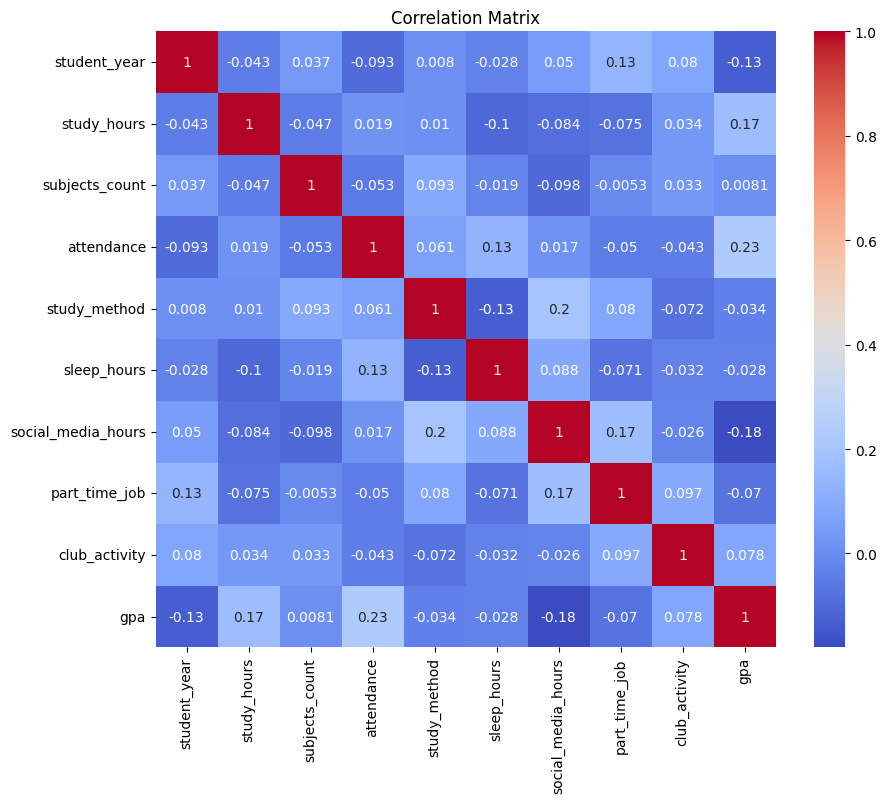

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(data.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

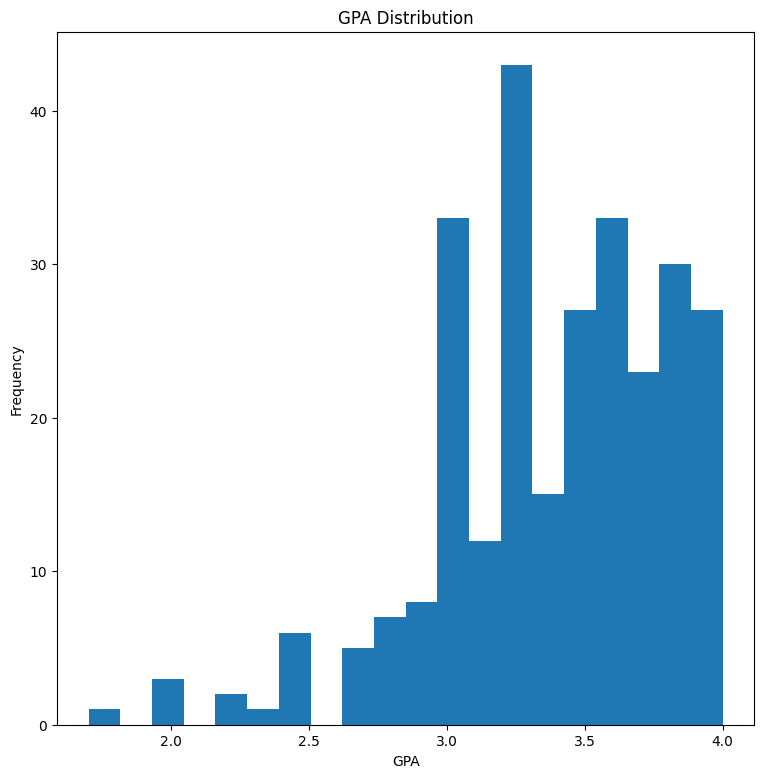

In [ ]:
# GPA DISTRIBUTION

plt.figure(figsize=(9,9))

plt.hist(data["gpa"], bins=20)

plt.xlabel("GPA")

plt.ylabel("Frequency")

plt.title("GPA Distribution")

plt.show()

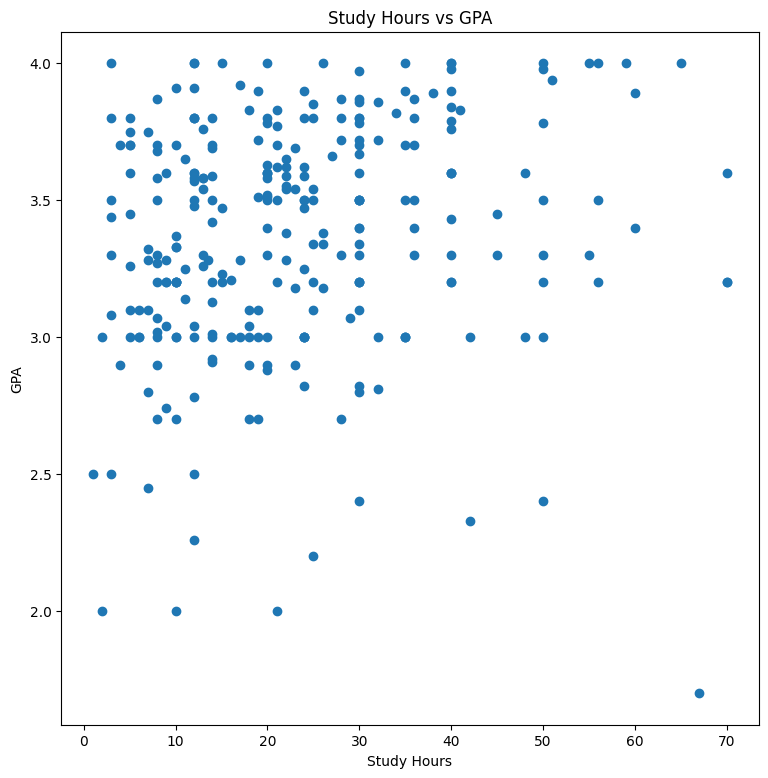

In [ ]:
# STUDY HOURS VS GPA

plt.figure(figsize=(9,9))

plt.scatter(data["study_hours"], data["gpa"])

plt.xlabel("Study Hours")

plt.ylabel("GPA")

plt.title("Study Hours vs GPA")

plt.show()

In [ ]:
# SPLIT DATA

x= data.drop("gpa", axis=1)

y = data["gpa"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(x_test).round(1)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.40625
RMSE: 0.5263774446969725
R2: 0.04729786255874313


<function matplotlib.pyplot.show(close=None, block=None)>

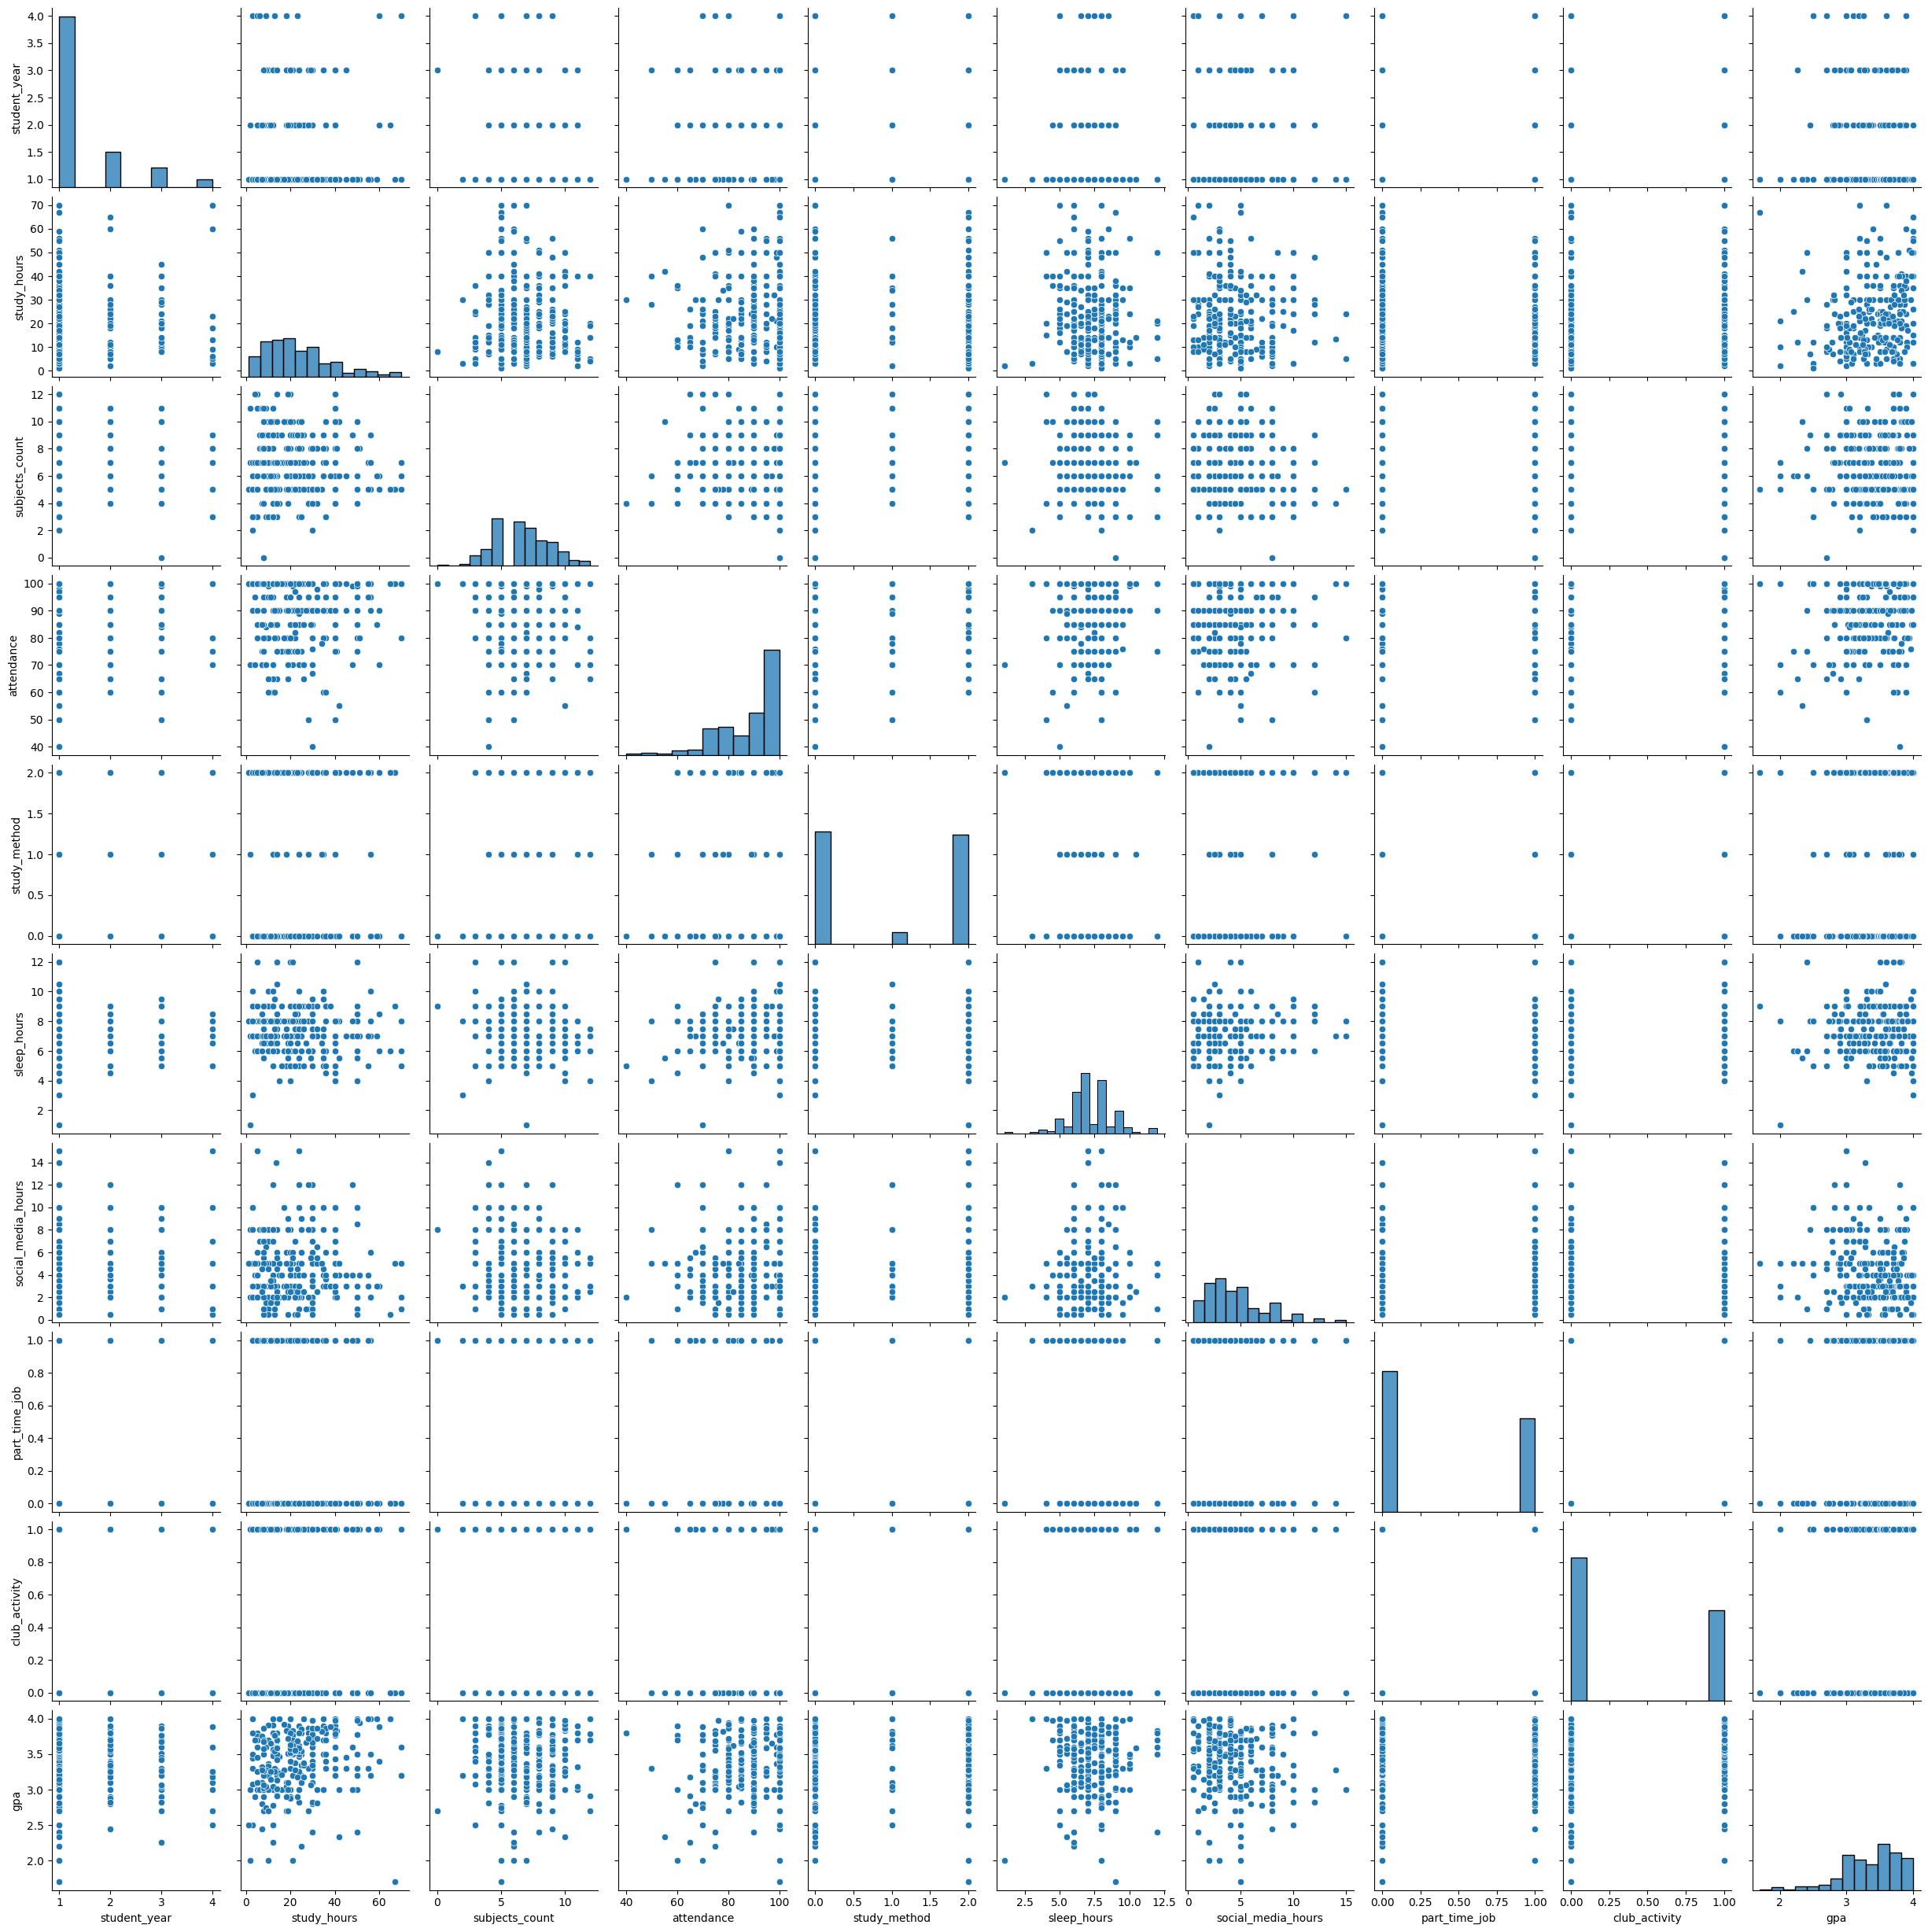

In [ ]:
sns.pairplot(data)
plt.show

In [28]:
new_student = pd.DataFrame([{
    "student_year": 1,
    "study_hours": 20,
    "subjects_count": 8,
    "attendance": 100,
    "study_method": 1,
    "sleep_hours": 6,
    "social_media_hours": 3,
    "part_time_job": 0,
    "club_activity": 1
}])
predicted_gpa = model.predict(new_student)[0]

print("Predicted GPA:", predicted_gpa)


Predicted GPA: 3.5641273452958075
